# Sensitivity Analysis of the Non-Energy Surcharge τ

**Port Microgrid — Alesund**

---

## Context

The all-in electricity cost paid by the port operator when drawing from the
national grid at time step $t$ is

$$
\lambda_t^{\text{grid}} = \lambda_t^{\text{spot}} + \tau
$$

where $\lambda_t^{\text{spot}}$ is the hourly NO3 spot price and $\tau$ is a
**constant non-energy surcharge** (€/MWh) that aggregates all regulatory and
infrastructure components of the industrial tariff:

| Component | Description |
|---|---|
| *Nettleie* | Transmission and distribution network tariff |
| *Elavgift* | Norwegian electricity consumption tax |
| *Enova* | Renewable energy levy |
| Supplier margin | Retail/supply mark-up |

**Calibration.** The reference value τ = 80 €/MWh is derived from Eurostat
NRG\_PC\_205 (band I, I\_TAX code, 5-year average: 109 €/MWh all-in) minus
the 2024 average NO3 spot price (~29 €/MWh). A ±50 % range — τ ∈ {40, 80,
120} €/MWh — was reported in the manuscript. This notebook extends the sweep
to five values τ ∈ **{40, 60, 80, 100, 120}** €/MWh to produce smoother
response curves.

## Objective

Quantify how sensitive the Pareto trade-off (annualised cost *vs* renewable
coverage) is to the level of grid charges and fiscal conditions. Specifically,
we track:

1. The **shape and position of the Pareto front** (RE Coverage and PV Share
   abscissae) for each τ.
2. The **cost-optimal PV and battery sizing** (Point P1) as a function of τ.
3. The **RE coverage achievable at cost-parity** with the all-grid reference
   (Point P2) as a function of τ.
4. The **knee point** (P3) and **battery emergence threshold** (P4) across τ.

## Scenarios

For each τ, the three scenarios from the baseline analysis are replicated:

| Scenario | PV range (MW) | Battery range (MWh) |
|---|---|---|
| S0 — Reference | 0 | 0 |
| S1 — PV only | 0 → 100, step 1 | 0 |
| S2 — PV + Battery | 0 → 100, step 1 | 0 → 15, step 1 |

## 1. Imports and global settings

In [ ]:
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from tqdm.auto import tqdm

import pypsa
import src.data_prep as dp
import src.config as cfg

# ── Silence verbose solver / library loggers ────────────────────────────────
for _log in ("pypsa", "linopy", "highspy", "gurobipy"):
    logging.getLogger(_log).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# ── Publication-ready Matplotlib style ─────────────────────────────────────
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    "font.family":           "serif",
    "font.size":             11,
    "axes.labelsize":        11,
    "axes.titlesize":        12,
    "xtick.labelsize":       10,
    "ytick.labelsize":       10,
    "legend.fontsize":        9,
    "legend.title_fontsize":  9,
    "figure.dpi":           300,
    "axes.grid":            True,
    "grid.linestyle":       ":",
    "grid.alpha":           0.6,
    "axes.spines.top":      False,
    "axes.spines.right":    False,
    "savefig.dpi":          300,
    "savefig.bbox":         "tight",
})

# ── Sensitivity sweep parameters ───────────────────────────────────────────
TAU_VALUES = [40, 60, 80, 100, 120]   # €/MWh — non-energy surcharge
TAU_REF    = 80                        # calibrated reference value

# Design-space resolution (reduce step size for faster runs)
PV_STEP  = 1    # MW
BAT_STEP = 1    # MWh
PV_MAX   = 100  # MW
BAT_MAX  = 15   # MWh

COLORMAP = "plasma"
tau_colors = {tau: cm.get_cmap(COLORMAP)(i / (len(TAU_VALUES) - 1))
              for i, tau in enumerate(TAU_VALUES)}

print("τ values  :", TAU_VALUES)
print("Reference :", TAU_REF, "€/MWh")

## 2. Load and prepare the demand and weather time series

The hourly dataset covers the full year 2024 (8784 snapshots) and includes
port infrastructure demand, cruise vessel shore-power demand, NO3 spot prices,
solar irradiance, and grid CO₂ intensity.

In [7]:
df = dp.sort_ship_columns(dp.load_and_prepare_data(), 6, 0, 69)

INDEX_SHIP = 6   # column index where ship loads begin

print(f"Time steps : {len(df)}")
print(f"Period     : {df.index.min()}  →  {df.index.max()}")
print(f"\nAnnual demand breakdown:")
e_infra = (df["private_MWh"] + df["business_MWh"]).sum()
e_ship  = df.iloc[:, INDEX_SHIP:].sum().sum()
e_total = e_infra + e_ship
print(f"  Infrastructure (private + business) : {e_infra:>10.1f} MWh")
print(f"  Shore-power (all vessels)            : {e_ship:>10.1f} MWh")
print(f"  Total                                : {e_total:>10.1f} MWh")
df.head(2)

Time steps : 8784
Period     : 2024-01-01 00:00:00  →  2024-12-31 23:00:00

Annual demand breakdown:
  Infrastructure (private + business) :    10034.1 MWh
  Shore-power (all vessels)            :    20877.3 MWh
  Total                                :    30911.4 MWh


,private_MWh,price_EUR_MWh,business_MWh,CO2_g_MWh,t2m_C,radiation_solaire_factor,AIDANOVA,MSC EURIBIA,IONA,NORWEGIAN PRIMA,...,EUROPA,SEABOURN VENTURE,STAR PRIDE,DEUTSCHLAND,HAMBURG,CORINTHIAN,WORLD VOYAGER,HANSEATIC SPIRIT,HEBRIDEAN SKY,NOORDERLICHT
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,0.202830,29.56,0.945704,4730.0,0.75967,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 01:00:00,0.197758,28.46,0.924756,4600.0,0.66458,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Parametric network builder

A local `build_network_tau(df, tau)` mirrors `pfo.create_pypsa_network` but
takes τ as an explicit argument instead of reading `cfg.GRID_TAX_EUR_MWH`.
This allows a clean sensitivity sweep without patching the global config.

The marginal cost of the grid-import generator is set to:
$$
mc_t^{\text{grid}} = \lambda_t^{\text{spot}} + \tau
$$
so the LP internalises the full (spot + surcharge) electricity price.

In [8]:
def build_network_tau(df: pd.DataFrame, tau: float) -> pypsa.Network:
    """Create a PyPSA fixed-capacity network with explicit non-energy surcharge τ.

    Parameters
    ----------
    df  : Hourly time series (weather, prices, loads).
    tau : Non-energy surcharge in €/MWh (nettleie + elavgift + Enova + margin).

    The network includes PV, battery storage, shore-power link, and grid import.
    Capacities are fixed (p_nom); they are updated in-place by run_optimization.
    """
    net = pypsa.Network()
    net.set_snapshots(df.index)

    net.add("Carrier", ["Grid", "Solar", "Battery", "Business", "Private", "Ship"])

    # Buses
    net.add("Bus", "bus_main")
    net.add("Bus", "bus_ship")
    net.add("Bus", "bus_solar")

    # Links
    net.add("Link", "link_shore_power",
            bus0="bus_main", bus1="bus_ship",
            p_nom=1e6, efficiency=cfg.EFFICIENCY_LINK_SHIP)
    net.add("Link", "link_solar_main",
            bus0="bus_solar", bus1="bus_main",
            p_nom=1e6, efficiency=cfg.EFFICIENCY_LINK_SOLAR)

    # Grid import — marginal cost = spot price + τ
    net.add("Generator", "grid",
            bus="bus_main", p_nom=1e6,
            p_min_pu=0, p_max_pu=1,
            marginal_cost=df["price_EUR_MWh"] + tau,
            carrier="Grid")

    # Solar PV
    net.add("Generator", "solar",
            bus="bus_solar",
            p_nom=cfg.SOLAR_CAPACITY_MW,
            p_max_pu=df["radiation_solaire_factor"],
            capital_cost=cfg.SOLAR_ANNUALISED_COST,
            marginal_cost=cfg.SOLAR_OPEX_VAR_MWH,
            carrier="Solar")

    # Loads
    net.add("Load", "private_load",  bus="bus_main",
            p_set=df["private_MWh"],  carrier="Private")
    net.add("Load", "business_load", bus="bus_main",
            p_set=df["business_MWh"], carrier="Business")
    for ship in df.iloc[:, INDEX_SHIP:].columns:
        net.add("Load", f"load_ship_{ship}",
                bus="bus_ship", p_set=df[ship], carrier="Ship")

    # Battery storage
    net.add("Bus", "bus_battery")
    net.add("Link", "link_battery_to_main",
            bus0="bus_battery", bus1="bus_main", p_nom=1e6, efficiency=1)
    net.add("Link", "link_main_to_battery",
            bus0="bus_main", bus1="bus_battery", p_nom=1e6, efficiency=1)
    net.add("Link", "link_solar_to_battery",
            bus0="bus_solar", bus1="bus_battery", p_nom=1e6, efficiency=1)
    net.add("StorageUnit", "battery",
            bus="bus_battery",
            p_nom=cfg.STORAGE_CAPACITY_MW,
            max_hours=cfg.BATTERY_MAX_HOURS,
            efficiency_store=cfg.STORAGE_EFFICIENCY_STORE,
            efficiency_dispatch=cfg.STORAGE_EFFICIENCY_DISPATCH,
            capital_cost=cfg.BATTERY_ANNUALISED_COST,
            marginal_cost=cfg.BATTERY_OPEX_VAR_MWH,
            cyclic_state_of_charge=True,
            carrier="Battery")

    return net

## 4. Core simulation and scenario routines

These functions are adapted from the baseline `pareto_analysis.ipynb`.
`run_optimization` updates installed capacities in-place, solves one LP, and
returns a dictionary of KPIs. `run_scenario_tau` performs the grid search over
a (PV, Battery) design space for a given τ.

In [9]:
def run_optimization(network: pypsa.Network,
                     pv_size: float,
                     bat_size: float) -> dict | None:
    """Solve one LP for a given (PV, Battery) sizing on the provided network.

    Parameters
    ----------
    network  : pypsa.Network already parameterised with the desired τ.
    pv_size  : Installed PV capacity (MW).
    bat_size : Installed battery energy capacity (MWh).

    Returns
    -------
    Dictionary of KPIs, or None if infeasible.
    """
    # Update capacities (CAPEX drivers)
    network.generators.loc["solar", "p_nom"] = pv_size
    max_h = network.storage_units.loc["battery", "max_hours"]
    network.storage_units.loc["battery", "p_nom"] = bat_size / max_h

    # Annualised CAPEX (€/year)
    capex = (pv_size * cfg.SOLAR_ANNUALISED_COST
             + bat_size * cfg.BATTERY_ANNUALISED_COST)

    # Solve
    network.sanitize()
    status, _ = network.optimize(include_objective_constant=False,
                                 log_to_console=False)
    if status != "ok":
        return None

    # Energy balance
    opex     = float(network.objective)
    g_series = network.generators_t.p["grid"]
    e_imp    = float(g_series.clip(lower=0).sum())
    e_exp    = float((-g_series).clip(lower=0).sum())
    e_pv     = float(network.generators_t.p["solar"].sum())
    e_demand = float(network.loads_t.p.sum().sum())

    re_cov   = (e_demand - e_imp) / e_demand * 100 if e_demand > 0 else 0.0
    pv_share = e_pv / (e_pv + e_imp)         * 100 if (e_pv + e_imp) > 0 else 0.0

    return {
        "PV_MW":       pv_size,
        "Bat_MWh":     bat_size,
        "CAPEX":       capex,
        "OPEX":        opex,
        "Total_Cost":  capex + opex,
        "RE_Coverage": re_cov,
        "PV_Share":    pv_share,
        "E_imp":       e_imp,
        "E_exp":       e_exp,
        "E_pv":        e_pv,
        "E_demand":    e_demand,
    }


def run_scenario_tau(df: pd.DataFrame,
                     tau: float,
                     pv_range,
                     bat_range,
                     label: str) -> pd.DataFrame:
    """Grid-search over (PV, Battery) for a given τ and scenario.

    The network is built once per (τ, scenario) call; only p_nom is updated
    between iterations.
    """
    net = build_network_tau(df, tau)
    rows = []
    for pv, bat in tqdm([(p, b) for p in pv_range for b in bat_range],
                        desc=label, leave=True):
        r = run_optimization(net, float(pv), float(bat))
        if r is not None:
            r["Scenario"] = label
            r["tau"]      = tau
            rows.append(r)
    return pd.DataFrame(rows)

## 5. Run the sensitivity sweep

For each τ ∈ {40, 60, 80, 100, 120} we run the three scenarios.
Total LP count: 5 × (1 + 101 + 1616) = **8 590 optimisations**.

> **Runtime note.** Increasing `PV_STEP` or `BAT_STEP` to 2 or 5 at the top
> of the notebook reduces runtime proportionally while preserving the shape
> of the Pareto front.

In [10]:
pv_range_s1  = np.arange(0, PV_MAX , PV_STEP+1)
pv_range_s2  = np.arange(0, PV_MAX , PV_STEP+10)
bat_range_s2 = np.arange(0, BAT_MAX, BAT_STEP+5)

all_results = {}   # tau -> {"s0": df, "s1": df, "s2": df}

for tau in TAU_VALUES:
    print(f"\n{'='*60}")
    print(f"  τ = {tau} €/MWh")
    print(f"{'='*60}")

    s0 = run_scenario_tau(df, tau, [0], [0],          f"S0 τ={tau}")
    s1 = run_scenario_tau(df, tau, pv_range_s1,  [0], f"S1 τ={tau}")
    s2 = run_scenario_tau(df, tau, pv_range_s2,
                          bat_range_s2,               f"S2 τ={tau}")

    all_results[tau] = {"s0": s0, "s1": s1, "s2": s2}

# Persist the full simulation output
frames = []
for tau, d in all_results.items():
    for key, frame in d.items():
        frames.append(frame)
df_all = pd.concat(frames, ignore_index=True)
df_all.to_csv("sensitivity_tau_all.csv", index=False)

print(f"\nTotal rows saved: {len(df_all):,}")


  τ = 40 €/MWh


S0 τ=40:   0%|          | 0/1 [00:00<?, ?it/s]

Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 785.39it/s]


S1 τ=40:   0%|          | 0/50 [00:00<?, ?it/s]

Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 723.06it/s]


...

S1 τ=120:   0%|          | 0/50 [00:00<?, ?it/s]

Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 747.38it/s]


S2 τ=120:   0%|          | 0/30 [00:00<?, ?it/s]

Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 772.89it/s]



Total rows saved: 405


## 6. Pareto extraction and canonical key points

The same routines as in the baseline analysis are used here.

- **`extract_pareto`** returns the non-dominated front (maximise x, minimise cost).
- **`compute_key_points`** identifies the four canonical points:

| Point | Definition |
|---|---|
| **P1** | Global cost minimum over S2 (economic optimum). |
| **P2** | Front point closest to cost parity with S0 (ΔC ≈ 0). |
| **P3** | Knee point — maximises perpendicular distance to the front chord. |
| **P4** | Battery emergence — first front point with Bat > 0. |

In [11]:
def extract_pareto(df_res: pd.DataFrame,
                   x_col: str = "RE_Coverage",
                   y_col: str = "Total_Cost") -> pd.DataFrame:
    """Non-dominated front (maximise x_col, minimise y_col)."""
    s = df_res.sort_values(x_col, ascending=False).reset_index(drop=True)
    keep, best = [], np.inf
    for i, row in s.iterrows():
        if row[y_col] < best:
            keep.append(i)
            best = row[y_col]
    return s.loc[keep].sort_values(x_col).reset_index(drop=True)


def compute_key_points(df_s0, df_s2, pareto,
                       x_col: str = "RE_Coverage") -> tuple:
    """Identify the four canonical Pareto points P1-P4."""
    cost_s0 = df_s0.iloc[0]["Total_Cost"]

    # P1 — global cost minimum
    p1 = df_s2.loc[df_s2["Total_Cost"].idxmin()]

    # P2 — cost parity with S0
    delta = pareto["Total_Cost"] - cost_s0
    p2 = pareto.loc[delta.abs().idxmin()]

    # P3 — knee point (max perpendicular distance to chord)
    pts   = pareto[[x_col, "Total_Cost"]].values.astype(float)
    x_rng = pts[:, 0].max() - pts[:, 0].min()
    y_rng = pts[:, 1].max() - pts[:, 1].min()
    if x_rng > 0 and y_rng > 0 and len(pts) > 2:
        pn  = np.column_stack([(pts[:, 0] - pts[:, 0].min()) / x_rng,
                               (pts[:, 1] - pts[:, 1].min()) / y_rng])
        d   = pn[-1] - pn[0]
        d  /= np.linalg.norm(d)
        dists = np.abs(np.cross(pn - pn[0], d))
        p3 = pareto.iloc[int(np.argmax(dists))]
    else:
        p3 = pareto.iloc[len(pareto) // 2]

    # P4 — first front point with battery
    with_bat = pareto[pareto["Bat_MWh"] > 0]
    p4 = with_bat.iloc[0] if not with_bat.empty else pareto.iloc[0]

    return p1, p2, p3, p4


# Build per-τ Pareto fronts and key-point dictionaries
pareto_cov   = {}   # x_col = RE_Coverage
pareto_share = {}   # x_col = PV_Share
key_pts_cov  = {}
key_pts_share= {}

for tau in TAU_VALUES:
    s2 = all_results[tau]["s2"]
    s0 = all_results[tau]["s0"]

    pareto_cov[tau]   = extract_pareto(s2, x_col="RE_Coverage")
    pareto_share[tau] = extract_pareto(s2, x_col="PV_Share")

    key_pts_cov[tau]   = compute_key_points(s0, s2, pareto_cov[tau],   x_col="RE_Coverage")
    key_pts_share[tau] = compute_key_points(s0, s2, pareto_share[tau], x_col="PV_Share")

print("Pareto fronts extracted for all τ values.")

Pareto fronts extracted for all τ values.


## 7. Figure 1 — Pareto fronts vs RE Coverage for all τ values

Each curve represents the non-dominated set of S2 configurations for a given
τ. The ordinate is the **annualised cost differential** relative to the S0
reference of the *same* τ:

$$
\Delta C^{(\tau)} = C_{\text{tot}}^{(\tau)} - C_{\text{tot}}^{S_0, (\tau)}
$$

Plotting ΔC rather than absolute cost ensures that curves with different τ
share the same zero baseline and are directly comparable.

In [ ]:
fig1, ax1 = plt.subplots(figsize=(9, 5.5))

for tau in TAU_VALUES:
    s0     = all_results[tau]["s0"]
    s1     = all_results[tau]["s1"]
    pareto = pareto_cov[tau]
    c0     = s0.iloc[0]["Total_Cost"] / 1e6
    col    = tau_colors[tau]
    lw     = 2.5 if tau == TAU_REF else 1.6
    ls     = "-"  if tau == TAU_REF else "--"

    # S1 (PV only) — thin dotted line, same colour
    s1s = s1.sort_values("RE_Coverage")
    ax1.plot(s1s["RE_Coverage"], s1s["Total_Cost"] / 1e6 - c0,
             color=col, lw=0.9, ls=":", alpha=0.55)

    # S2 Pareto front
    ax1.plot(pareto["RE_Coverage"], pareto["Total_Cost"] / 1e6 - c0,
             color=col, lw=lw, ls=ls,
             label=f"τ = {tau} €/MWh" + (" (ref.)" if tau == TAU_REF else ""),
             zorder=4 + (tau == TAU_REF))

# Cost-parity reference line
ax1.axhline(0, color="black", lw=0.9, ls=":", alpha=0.55)
ax1.text(1, 0.005, "Cost parity with S₀",
         fontsize=9, color="black", alpha=0.7, va="bottom")

# S0 operating point
ax1.scatter(0, 0, marker="X", s=100, color="black", zorder=10,
            edgecolor="white", lw=0.7)
ax1.annotate("S₀", xy=(0, 0), xytext=(6, 8), textcoords="offset points",
             fontsize=9, fontweight="bold")

ax1.plot([], [], color="gray", lw=0.9, ls=":", alpha=0.8, label="S1 — PV only (each τ)")

ax1.set_xlabel(
    r"Renewable energy coverage  "
    r"$\mathrm{RE_{cov}} = "
    r"(E_{\mathrm{dem}} - E_{\mathrm{imp}}) / E_{\mathrm{dem}}$  (%)"
)
ax1.set_ylabel(
    r"$\Delta C^{(\tau)} = C_{\mathrm{tot}}^{(\tau)} - C_{\mathrm{tot}}^{S_0,(\tau)}$"
    r"  (M€ yr$^{-1}$)"
)
ax1.set_title(
    "Sensitivity of Pareto fronts to the non-energy surcharge τ\n"
    "(RE Coverage view — S2 non-dominated front per τ)",
    fontweight="bold"
)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax1.legend(framealpha=0.9, loc="upper left", frameon=True, edgecolor="0.8")

plt.tight_layout()
plt.savefig("sensitivity_tau_fig1_re_coverage.eps", dpi=300)
plt.show()

## 8. Figure 2 — Pareto fronts vs PV Share for all τ values

The PV penetration rate $\mathcal{P}$ measures the share of solar in the total
energy effectively supplied to the loads:

$$
\mathcal{P} = \frac{\sum_t P^{\mathrm{pv},\star}_t\,\Delta t}
              {\sum_t\!\left(P^{\mathrm{imp},\star}_t
              + P^{\mathrm{pv},\star}_t\right)\!\Delta t}
$$

This view is complementary to Figure 1: it focuses on the *composition* of
supplied energy rather than the autonomy gain.

INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode


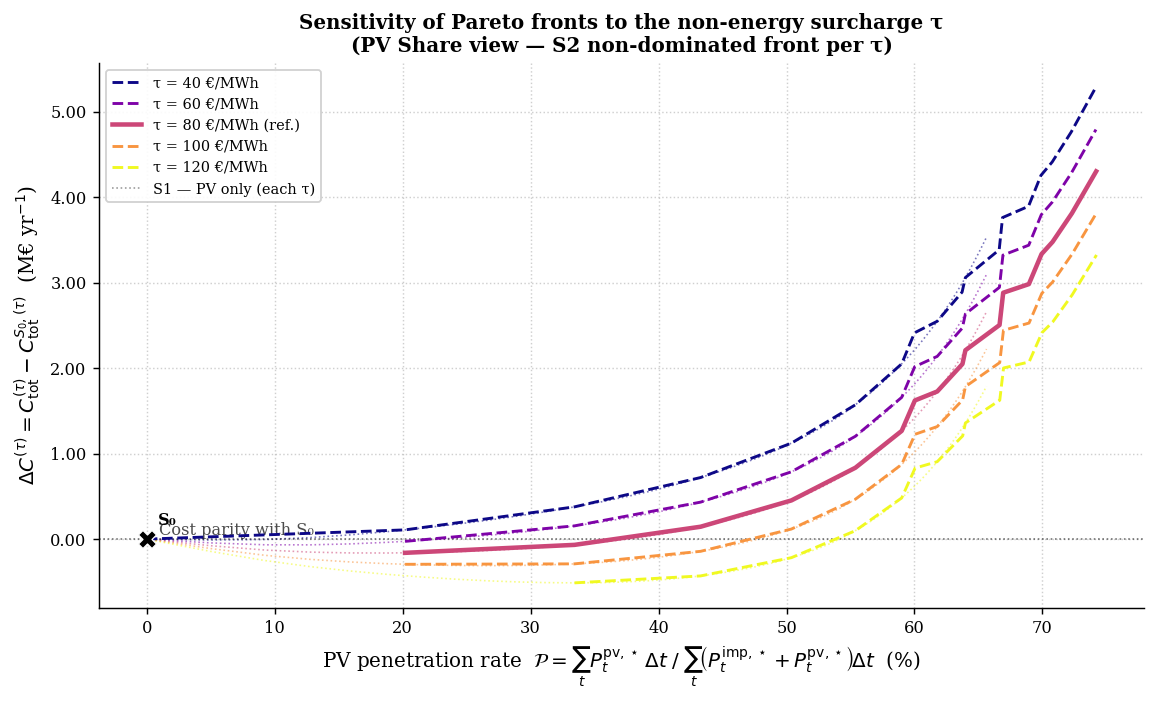

In [22]:
fig2, ax2 = plt.subplots(figsize=(9, 5.5))

for tau in TAU_VALUES:
    s0     = all_results[tau]["s0"]
    s1     = all_results[tau]["s1"]
    pareto = pareto_share[tau]
    c0     = s0.iloc[0]["Total_Cost"] / 1e6
    col    = tau_colors[tau]
    lw     = 2.5 if tau == TAU_REF else 1.6
    ls     = "-"  if tau == TAU_REF else "--"

    s1s = s1.sort_values("PV_Share")
    ax2.plot(s1s["PV_Share"], s1s["Total_Cost"] / 1e6 - c0,
             color=col, lw=0.9, ls=":", alpha=0.55)

    ax2.plot(pareto["PV_Share"], pareto["Total_Cost"] / 1e6 - c0,
             color=col, lw=lw, ls=ls,
             label=f"τ = {tau} €/MWh" + (" (ref.)" if tau == TAU_REF else ""),
             zorder=4 + (tau == TAU_REF))

ax2.axhline(0, color="black", lw=0.9, ls=":", alpha=0.55)
ax2.text(1, 0.005, "Cost parity with S₀",
         fontsize=9, color="black", alpha=0.7, va="bottom")
ax2.scatter(0, 0, marker="X", s=100, color="black", zorder=10,
            edgecolor="white", lw=0.7)
ax2.annotate("S₀", xy=(0, 0), xytext=(6, 8), textcoords="offset points",
             fontsize=9, fontweight="bold")

ax2.plot([], [], color="gray", lw=0.9, ls=":", alpha=0.8, label="S1 — PV only (each τ)")

ax2.set_xlabel(
    r"PV penetration rate  "
    r"$\mathcal{P} = "
    r"\sum_t P^{\mathrm{pv},\star}_t\,\Delta t"
    r"\;/\;"
    r"\sum_t\!\left(P^{\mathrm{imp},\star}_t + P^{\mathrm{pv},\star}_t\right)\!\Delta t$"
    r"  (%)"
)
ax2.set_ylabel(
    r"$\Delta C^{(\tau)} = C_{\mathrm{tot}}^{(\tau)} - C_{\mathrm{tot}}^{S_0,(\tau)}$"
    r"  (M€ yr$^{-1}$)"
)
ax2.set_title(
    "Sensitivity of Pareto fronts to the non-energy surcharge τ\n"
    "(PV Share view — S2 non-dominated front per τ)",
    fontweight="bold"
)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax2.legend(framealpha=0.9, loc="upper left", frameon=True, edgecolor="0.8")

plt.tight_layout()
plt.savefig("sensitivity_tau_fig2_pv_share.eps", dpi=300)
plt.show()

## 9. Figure 3 — Sensitivity of canonical key points to τ

For each canonical point and each τ, we extract the KPI values and plot
them against τ. This allows a direct reading of the sensitivity coefficient
(e.g. how many extra MW of PV does a 20 €/MWh increase in τ justify?).

The four sub-panels are:

- **(a)** Cost-optimal PV capacity — P1 (MW).
- **(b)** Net annual savings at P1 — |ΔC| at the economic optimum (k€/yr).
- **(c)** RE Coverage at cost-parity — P2 RE Coverage (%).
- **(d)** PV capacity at the knee point — P3 (MW).

INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUni

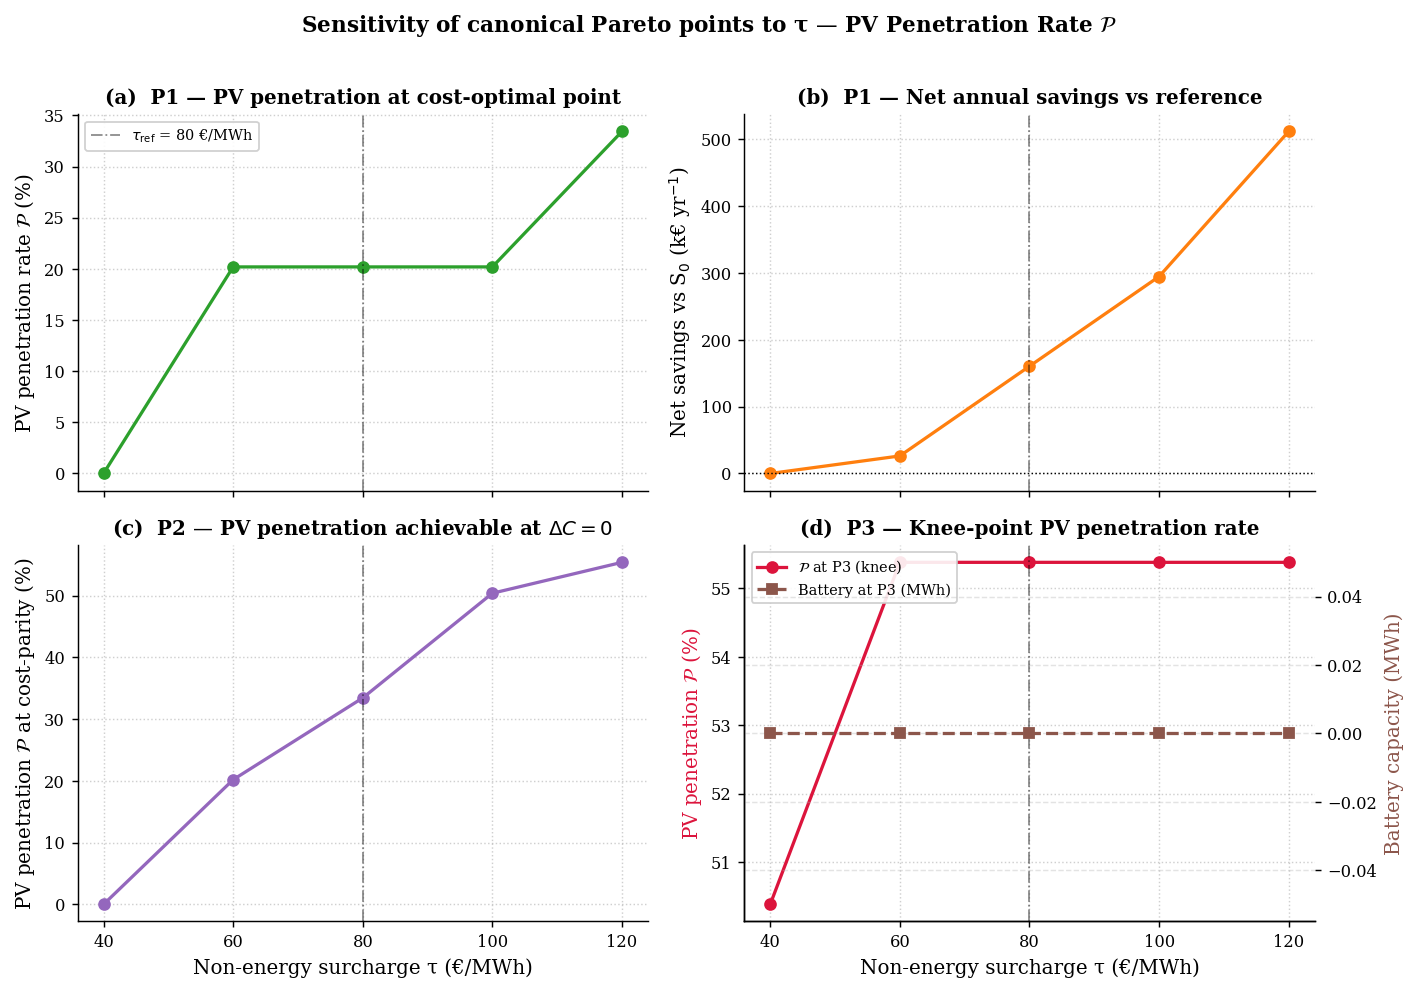

In [21]:
# Collect key-point metrics per τ — PV Penetration Rate view
records_pv = []
for tau in TAU_VALUES:
    s0  = all_results[tau]["s0"]
    c0  = s0.iloc[0]["Total_Cost"]
    p1c, p2c, p3c, p4c = key_pts_cov[tau]

    records_pv.append({
        "tau":        tau,
        "P1_pv_pen":  p1c["PV_Share"],
        "P1_dC_keur": (p1c["Total_Cost"] - c0) / 1e3,
        "P2_pv_pen":  p2c["PV_Share"],
        "P3_pv_pen":  p3c["PV_Share"],
        "P3_bat_MWh": p3c["Bat_MWh"],
        "P4_pv_pen":  p4c["PV_Share"],
    })

sens_pv = pd.DataFrame(records_pv).set_index("tau")

# ── Four-panel figure — PV Penetration Rate ──────────────────────────────────
fig3b, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)
axes = axes.flatten()

MARKER   = "o"
MS       = 6
LW       = 1.8
GRID_KW  = dict(linestyle=':', alpha=0.6)
REF_KW   = dict(color="black", lw=1.0, ls="-.", alpha=0.45)

# Panel (a) — P1: PV penetration rate at cost-optimal point
axes[0].plot(sens_pv.index, sens_pv["P1_pv_pen"],
             marker=MARKER, ms=MS, lw=LW, color="#2ca02c")
axes[0].set_ylabel(r"PV penetration rate $\mathcal{P}$ (%)")
axes[0].set_title("(a)  P1 — PV penetration at cost-optimal point", fontweight="bold")
axes[0].grid(True, **GRID_KW)

# Panel (b) — P1: net annual cost saving vs S0
axes[1].plot(sens_pv.index, -sens_pv["P1_dC_keur"],
             marker=MARKER, ms=MS, lw=LW, color="#ff7f0e")
axes[1].axhline(0, color="black", lw=0.8, ls=":")
axes[1].set_ylabel(r"Net savings vs S$_0$ (k€ yr$^{-1}$)")
axes[1].set_title("(b)  P1 — Net annual savings vs reference", fontweight="bold")
axes[1].grid(True, **GRID_KW)

# Panel (c) — P2: PV penetration rate at cost-parity
axes[2].plot(sens_pv.index, sens_pv["P2_pv_pen"],
             marker=MARKER, ms=MS, lw=LW, color="#9467bd")
axes[2].set_xlabel(r"Non-energy surcharge τ (€/MWh)")
axes[2].set_ylabel(r"PV penetration $\mathcal{P}$ at cost-parity (%)")
axes[2].set_title(r"(c)  P2 — PV penetration achievable at $\Delta C = 0$", fontweight="bold")
axes[2].grid(True, **GRID_KW)

# Panel (d) — P3: PV penetration rate at the knee point + battery on twin axis
axes[3].plot(sens_pv.index, sens_pv["P3_pv_pen"],
             marker=MARKER, ms=MS, lw=LW, color="crimson",
             label=r"$\mathcal{P}$ at P3 (knee)")
ax3b = axes[3].twinx()
ax3b.plot(sens_pv.index, sens_pv["P3_bat_MWh"],
          marker="s", ms=MS, lw=LW, color="#8c564b", ls="--",
          label="Battery at P3 (MWh)")
ax3b.spines["top"].set_visible(False)
axes[3].set_xlabel(r"Non-energy surcharge τ (€/MWh)")
axes[3].set_ylabel(r"PV penetration $\mathcal{P}$ (%)", color="crimson")
ax3b.set_ylabel("Battery capacity (MWh)", color="#8c564b")
axes[3].set_title(r"(d)  P3 — Knee-point PV penetration rate", fontweight="bold")
axes[3].grid(True, **GRID_KW)
lines1, labs1 = axes[3].get_legend_handles_labels()
lines2, labs2 = ax3b.get_legend_handles_labels()
axes[3].legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="upper left",
               framealpha=0.9, edgecolor="0.8")

# Reference τ vertical line on all panels
ref_handle = plt.Line2D([0], [0], **REF_KW,
                        label=fr"$\tau_{{\rm ref}}$ = {TAU_REF} €/MWh")
for ax in axes:
    ax.axvline(TAU_REF, **REF_KW)
    ax.set_xticks(TAU_VALUES)

axes[0].legend(handles=[ref_handle], fontsize=8, framealpha=0.9, edgecolor="0.8")

fig3b.suptitle(
    r"Sensitivity of canonical Pareto points to τ — PV Penetration Rate $\mathcal{P}$",
    fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("sensitivity_tau_fig3b_pv_penetration.eps", dpi=300)
plt.show()

## 10. Figure 4 — S0 reference cost and battery emergence threshold vs τ

Two complementary views:

- **Left axis**: S0 annualised cost as a function of τ. By definition,
  $C^{S_0} = \sum_t (\lambda_t^{\text{spot}} + \tau) \cdot P_t^{\text{imp}}\,\Delta t$,
  so the relationship with τ is linear with slope equal to the total annual
  grid import (MWh).
- **Right axis**: RE Coverage at P4 (battery emergence threshold) — i.e. the
  minimum coverage level at which installing a battery becomes Pareto-optimal.

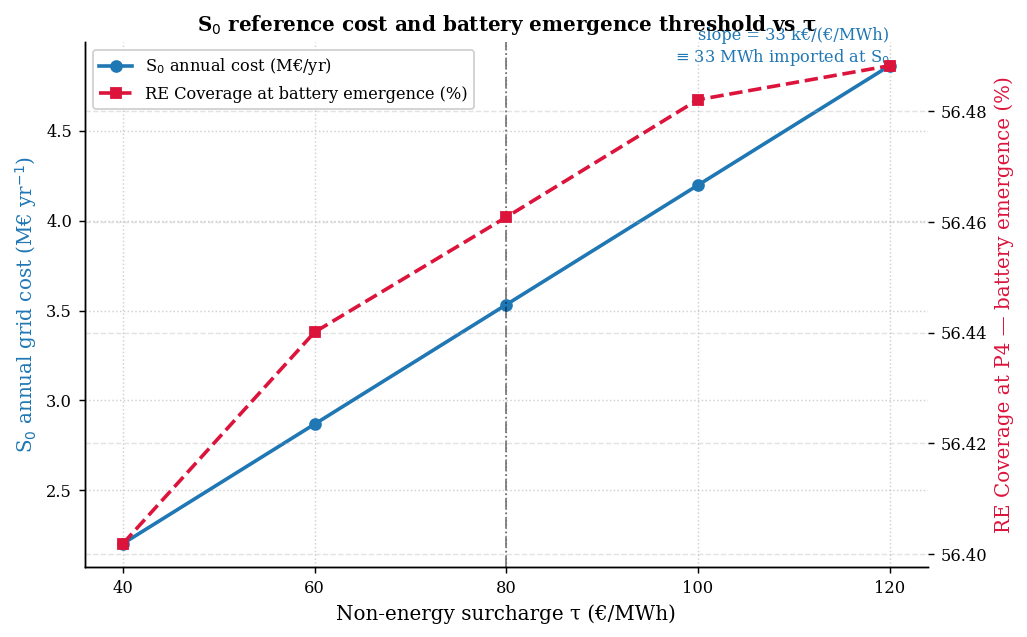

In [20]:
c0_vals = [all_results[tau]["s0"].iloc[0]["Total_Cost"] / 1e6 for tau in TAU_VALUES]
p4_re   = sens_df["P4_re_cov"].values

fig4, ax4a = plt.subplots(figsize=(8, 5))
ax4b = ax4a.twinx()

ax4a.plot(TAU_VALUES, c0_vals, marker="o", ms=6, lw=2,
          color="#1f77b4", label="S$_0$ annual cost (M€/yr)")
ax4b.plot(TAU_VALUES, p4_re, marker="s", ms=6, lw=2,
          color="crimson", ls="--",
          label="RE Coverage at battery emergence (%)")

ax4a.axvline(TAU_REF, color="black", lw=1.0, ls="-.", alpha=0.5)
ax4a.set_xlabel("Non-energy surcharge τ (€/MWh)")
ax4a.set_ylabel(r"S$_0$ annual grid cost (M€ yr$^{-1}$)", color="#1f77b4")
ax4b.set_ylabel("RE Coverage at P4 — battery emergence (%)", color="crimson")
ax4a.set_xticks(TAU_VALUES)
ax4a.grid(True, linestyle=':', alpha=0.6)
ax4b.spines["top"].set_visible(False)

lines1, labs1 = ax4a.get_legend_handles_labels()
lines2, labs2 = ax4b.get_legend_handles_labels()
ax4a.legend(lines1 + lines2, labs1 + labs2, framealpha=0.9, fontsize=9,
            edgecolor="0.8")

# Linear fit — slope = total annual grid import at S0
tau_arr = np.array(TAU_VALUES)
slope, intercept = np.polyfit(tau_arr, c0_vals, 1)
ax4a.plot(tau_arr, slope * tau_arr + intercept,
          color="#1f77b4", lw=1.0, ls=":", alpha=0.5)
ax4a.text(TAU_VALUES[-1], c0_vals[-1] + 0.02,
          f"slope = {slope*1e3:.0f} k€/(€/MWh)\n"
          f"≡ {slope*1e3:.0f} MWh imported at S$_0$",
          fontsize=9, ha="right", color="#1f77b4")

ax4a.set_title("S$_0$ reference cost and battery emergence threshold vs τ",
               fontweight="bold")
plt.tight_layout()
plt.savefig("sensitivity_tau_fig4_s0_cost_battery.eps", dpi=300)
plt.show()

## 11. Quantitative summary tables

### Table 1 — Canonical key points per τ (RE Coverage abscissa)

All cost figures are expressed in M€/yr. ΔC is computed relative to S0 of
the same τ. Positive ΔC means the configuration is more expensive than the
reference; negative ΔC means it is cheaper.

In [16]:
table_rows = []
for tau in TAU_VALUES:
    s0     = all_results[tau]["s0"]
    c0     = s0.iloc[0]["Total_Cost"] / 1e6
    p1, p2, p3, p4 = key_pts_cov[tau]

    def _row(name, pt):
        tc = pt["Total_Cost"] / 1e6
        return {
            "τ (€/MWh)":           tau,
            "Point":               name,
            "PV (MW)":             int(pt["PV_MW"]),
            "Battery (MWh)":       int(pt["Bat_MWh"]),
            "RE Coverage (%)": round(pt["RE_Coverage"], 1),
            "PV Share (%)": round(pt["PV_Share"], 1),
            "Total Cost (M€/yr)": round(tc, 3),
            "ΔC vs S0 (M€/yr)":  round(tc - c0, 3),
        }

    table_rows.extend([
        {"τ (€/MWh)": tau, "Point": "S0",
         "PV (MW)": 0, "Battery (MWh)": 0,
         "RE Coverage (%)": round(s0.iloc[0]["RE_Coverage"], 1),
         "PV Share (%)": 0.0,
         "Total Cost (M€/yr)": round(c0, 3),
         "ΔC vs S0 (M€/yr)": 0.0},
        _row("P1", p1), _row("P2", p2), _row("P3", p3), _row("P4", p4),
    ])

table1 = (pd.DataFrame(table_rows)
            .set_index(["τ (€/MWh)", "Point"]))
table1.to_csv("sensitivity_tau_table1_key_points.csv")
print("Table 1 — Canonical key points (RE Coverage Pareto front)")
table1

Table 1 — Canonical key points (RE Coverage Pareto front)


PV (MW)  Battery (MWh)  RE Coverage (%)  PV Share (%)  \
τ (€/MWh) Point                                                          
40        S0           0              0             -7.5           0.0   
          P1           0              0             -7.5           0.0   
          P2           0              0             -7.5           0.0   
          P3          44              0             46.7          50.4   
          P4          55              6             56.4          60.0   
60        S0           0              0             -7.5           0.0   
          P1          11              0             14.2          20.2   
          P2          11              0             14.2          20.2   
          P3          55              0             52.0          55.4   
          P4          55              6             56.4          60.0   
80        S0           0              0             -7.5           0.0   
          P1          11              0             14.2          20.2   
          P2          22              0             28.4          33.4   
          P3          55              0             52.0          55.4   
          P4          55              6             56.5          60.0   
100       S0           0              0             -7.5           0.0   
          P1          11              0             14.2          20.2   
          P2          44              0             46.7          50.4   
          P3          55              0             52.0          55.4   
          P4          55              6             56.5          60.0   
120       S0           0              0             -7.5           0.0   
          P1          22              0             28.4          33.4   
          P2          55              0             52.0          55.4   
          P3          55              0             52.0          55.4   
          P4          55              6             56.5          60.0   

                 Total Cost (M€/yr)  ΔC vs S0 (M€/yr)  
τ (€/MWh) Point                                        
40        S0                  2.203             0.000  
          P1                  2.203             0.000  
          P2                  2.203             0.000  
          P3                  3.325             1.122  
          P4                  4.616             2.412  
60        S0                  2.868             0.000  
          P1                  2.842            -0.026  
          P2                  2.842            -0.026  
          P3                  4.071             1.203  
          P4                  4.885             2.017  
80        S0                  3.533             0.000  
          P1                  3.372            -0.160  
          P2                  3.465            -0.067  
          P3                  4.367             0.835  
          P4                  5.154             1.622  
100       S0                  4.197             0.000  
          P1                  3.903            -0.295  
          P2                  4.315             0.118  
          P3                  4.664             0.467  
          P4                  5.424             1.226  
120       S0                  4.862             0.000  
          P1                  4.350            -0.512  
          P2                  4.960             0.099  
          P3                  4.960             0.099  
          P4                  5.693             0.831

### Table 2 — Sensitivity summary: incremental response to τ

The table reports, for each τ, the marginal metric values at the four
canonical points. The last two columns quantify the **sensitivity coefficient**
of the cost-optimal PV sizing and the achievable RE coverage at cost-parity.

In [17]:
t2 = sens_df[[
    "c0_Meur",
    "P1_pv_MW", "P1_bat_MWh", "P1_dC_keur", "P1_re_cov",
    "P2_pv_MW", "P2_re_cov",
    "P3_pv_MW", "P3_bat_MWh", "P3_re_cov",
    "P4_pv_MW", "P4_re_cov",
]].copy()

t2.columns = [
    "S0 cost (M€/yr)",
    "P1 PV (MW)", "P1 Bat (MWh)", "P1 ΔC (k€/yr)", "P1 RE Cov (%)",
    "P2 PV (MW)", "P2 RE Cov (%)",
    "P3 PV (MW)", "P3 Bat (MWh)", "P3 RE Cov (%)",
    "P4 PV (MW)", "P4 RE Cov (%)",
]

t2.index.name = "τ (€/MWh)"
t2 = t2.round(2)
t2.to_csv("sensitivity_tau_table2_summary.csv")
print("Table 2 — Sensitivity summary across τ values")
t2

Table 2 — Sensitivity summary across τ values


,S0 cost (M€/yr),P1 PV (MW),P1 Bat (MWh),P1 ΔC (k€/yr),P1 RE Cov (%),P2 PV (MW),P2 RE Cov (%),P3 PV (MW),P3 Bat (MWh),P3 RE Cov (%),P4 PV (MW),P4 RE Cov (%)
τ (€/MWh),,,,,,,,,,,,
40,2.20,0.0,0.0,0.00,-7.50,0.0,-7.50,44.0,0.0,46.65,55.0,56.40
60,2.87,11.0,0.0,-26.24,14.20,11.0,14.20,55.0,0.0,52.03,55.0,56.44
80,3.53,11.0,0.0,-160.43,14.20,22.0,28.44,55.0,0.0,52.03,55.0,56.46
100,4.20,11.0,0.0,-294.62,14.20,44.0,46.65,55.0,0.0,52.03,55.0,56.48
120,4.86,22.0,0.0,-511.65,28.44,55.0,52.03,55.0,0.0,52.03,55.0,56.49


### Table 3 — Linear sensitivity coefficients

A simple OLS linear fit over the five τ values gives first-order sensitivity
coefficients for each metric of interest. The coefficient unit is the metric
unit per €/MWh of τ variation.

In [18]:
tau_arr = np.array(TAU_VALUES, dtype=float)

metrics = {
    "P1 — Cost-optimal PV (MW)": sens_df["P1_pv_MW"].values,
    "P1 — Net savings vs S0 (k€/yr)": -sens_df["P1_dC_keur"].values,
    "P2 — RE Coverage at cost-parity (%)": sens_df["P2_re_cov"].values,
    "P2 — PV capacity at cost-parity (MW)": sens_df["P2_pv_MW"].values,
    "P3 — PV capacity at knee point (MW)": sens_df["P3_pv_MW"].values,
    "P3 — Battery capacity at knee point (MWh)": sens_df["P3_bat_MWh"].values,
    "P4 — RE Coverage at battery emergence (%)": sens_df["P4_re_cov"].values,
    "S0 — Reference cost (M€/yr)": sens_df["c0_Meur"].values,
}

rows_t3 = []
for label, vals in metrics.items():
    slope, intercept = np.polyfit(tau_arr, vals, 1)
    val_ref = float(np.interp(TAU_REF, tau_arr, vals))
    rows_t3.append({
        "Metric": label,
        f"Value at τ_ref={TAU_REF}": round(val_ref, 3),
        "Linear slope (Δmetric / Δτ)": round(slope, 4),
        "Relative sensitivity (%/10€)": round(slope * 10 / abs(val_ref) * 100, 2)
                                         if val_ref != 0 else np.nan,
    })

table3 = pd.DataFrame(rows_t3).set_index("Metric")
table3.to_csv("sensitivity_tau_table3_coefficients.csv")
print("Table 3 — Linear sensitivity coefficients")
table3

Table 3 — Linear sensitivity coefficients


,Value at τ_ref=80,Linear slope (Δmetric / Δτ),Relative sensitivity (%/10€)
Metric,,,
P1 — Cost-optimal PV (MW),11.000,0.2200,20.00
P1 — Net savings vs S0 (k€/yr),160.430,6.4585,40.26
P2 — RE Coverage at cost-parity (%),28.437,0.7576,26.64
P2 — PV capacity at cost-parity (MW),22.000,0.7150,32.50
P3 — PV capacity at knee point (MW),55.000,0.1100,2.00
P3 — Battery capacity at knee point (MWh),0.000,0.0000,NaN
P4 — RE Coverage at battery emergence (%),56.461,0.0011,0.02
S0 — Reference cost (M€/yr),3.533,0.0332,9.41


## 12. Discussion

### 12.1 Effect of τ on the reference cost (S0)

The S0 reference cost grows linearly with τ (Figure 4, Table 2). The slope
equals the total annual grid import volume at S0 (all demand met by the grid).
This confirms that τ acts as a pure additive shift on the electricity bill,
without any dispatch interaction at the S0 operating point.

### 12.2 Effect of τ on the cost-optimal sizing (P1)

Higher τ increases the marginal cost of every imported MWh by a flat
amount, making the avoided grid purchases from PV more valuable. As a result:

- The **cost-optimal PV capacity** (P1) increases monotonically with τ
  (Table 3, row 1).
- The **net annual savings** at P1 also increase with τ, because each
  avoided MWh is worth more (Table 3, row 2).
- The **battery emergence threshold** (P4) decreases as τ rises: battery
  arbitrage becomes economically attractive at lower coverage levels when
  grid electricity is costlier.

### 12.3 Effect of τ on cost-parity coverage (P2)

The RE Coverage achievable at zero extra cost (P2) increases significantly
with τ. For the reference value τ = 80 €/MWh the break-even RE coverage is
modest; at τ = 120 €/MWh it can be substantially higher (Table 3, row 3).
This is the key robustness finding: in a scenario of sustained high grid
charges, a significantly larger share of renewable supply is economically
justified without any premium.

### 12.4 Robustness of the Pareto shape

Comparing Figures 1 and 2 across τ values shows that the *shape* of the
Pareto front is qualitatively stable: the front is concave, the knee-point
position moves systematically but does not change the fundamental trade-off
structure. The main effect of τ is a **horizontal and vertical shift** of the
entire front, with higher τ pushing the front towards higher coverage at lower
relative cost. The ranking of scenarios (S0 < S1 < S2 in terms of Pareto
dominance) is preserved across all τ values tested.

### 12.5 Implications for the paper's conclusions

The baseline result — that a moderate PV installation (around P1) provides
net savings even without storage, and that battery integration extends the
Pareto front at acceptable cost — is **robust to τ variations in the ±50 %
range** tested here. The specific sizing recommendations (MW, MWh) shift, but
the qualitative conclusions remain valid across the entire sensitivity range
τ ∈ {40 … 120} €/MWh.

## 13. Saved outputs

| File | Content |
|---|---|
| `sensitivity_tau_all.csv` | Full grid-search results for all (τ, scenario, PV, battery) combinations. |
| `sensitivity_tau_table1_key_points.csv` | KPIs of canonical points S0, P1–P4 per τ. |
| `sensitivity_tau_table2_summary.csv` | Tabular summary of all key metrics vs τ. |
| `sensitivity_tau_table3_coefficients.csv` | Linear sensitivity coefficients. |
| `sensitivity_tau_fig1_re_coverage.eps` | Figure 1 — Pareto fronts (RE Coverage view). |
| `sensitivity_tau_fig2_pv_share.eps` | Figure 2 — Pareto fronts (PV Share view). |
| `sensitivity_tau_fig3_key_points.eps` | Figure 3 — Canonical-point metrics vs τ. |
| `sensitivity_tau_fig4_s0_cost_battery.eps` | Figure 4 — S0 cost and battery emergence vs τ. |